In [34]:
#importing all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date
from scipy import stats
#to ignore warnings
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder


In [2]:
data = pd.read_csv('datasets/used_cars_data.csv')

# Analyzing the data

In [3]:
data.shape

(7253, 14)

In [4]:
#first 5 observations of the dataset
data.head()

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74


In [5]:
data.columns

Index(['S.No.', 'Name', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type',
       'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats',
       'New_Price', 'Price'],
      dtype='object')

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7253 entries, 0 to 7252
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   S.No.              7253 non-null   int64  
 1   Name               7253 non-null   object 
 2   Location           7253 non-null   object 
 3   Year               7253 non-null   int64  
 4   Kilometers_Driven  7253 non-null   int64  
 5   Fuel_Type          7253 non-null   object 
 6   Transmission       7253 non-null   object 
 7   Owner_Type         7253 non-null   object 
 8   Mileage            7251 non-null   object 
 9   Engine             7207 non-null   object 
 10  Power              7207 non-null   object 
 11  Seats              7200 non-null   float64
 12  New_Price          1006 non-null   object 
 13  Price              6019 non-null   float64
dtypes: float64(2), int64(3), object(9)
memory usage: 793.4+ KB


**data.info()** shows the variables Mileage, Engine, Power, Seats, New_Price, and Price have missing values. 
<br>Numeric variables like Mileage, Power are of datatype as  float64 and int64. 
<br>Categorical variables like Location, Fuel_Type, Transmission, and Owner Type are of object data type

In [7]:
# Check for Duplication
# Duplicated data can be handled or removed based on further analysis
data.nunique()

S.No.                7253
Name                 2041
Location               11
Year                   23
Kilometers_Driven    3660
Fuel_Type               5
Transmission            2
Owner_Type              4
Mileage               450
Engine                150
Power                 386
Seats                   9
New_Price             625
Price                1373
dtype: int64

In [8]:
print(data['Fuel_Type'].unique())

['CNG' 'Diesel' 'Petrol' 'LPG' 'Electric']


In [9]:
# Missing Values Calculation
data.isnull().sum()

S.No.                   0
Name                    0
Location                0
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 2
Engine                 46
Power                  46
Seats                  53
New_Price            6247
Price                1234
dtype: int64

In [10]:
# calculate the percentage of missing values in each column
(data.isnull().sum()/(len(data)))*100

S.No.                 0.000000
Name                  0.000000
Location              0.000000
Year                  0.000000
Kilometers_Driven     0.000000
Fuel_Type             0.000000
Transmission          0.000000
Owner_Type            0.000000
Mileage               0.027575
Engine                0.634220
Power                 0.634220
Seats                 0.730732
New_Price            86.129877
Price                17.013650
dtype: float64

# Data Reduction

In [11]:
# Remove S.No. column from data, assuming it don’t have any predictive power
data = data.drop(['S.No.'], axis = 1)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7253 entries, 0 to 7252
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               7253 non-null   object 
 1   Location           7253 non-null   object 
 2   Year               7253 non-null   int64  
 3   Kilometers_Driven  7253 non-null   int64  
 4   Fuel_Type          7253 non-null   object 
 5   Transmission       7253 non-null   object 
 6   Owner_Type         7253 non-null   object 
 7   Mileage            7251 non-null   object 
 8   Engine             7207 non-null   object 
 9   Power              7207 non-null   object 
 10  Seats              7200 non-null   float64
 11  New_Price          1006 non-null   object 
 12  Price              6019 non-null   float64
dtypes: float64(2), int64(2), object(9)
memory usage: 736.8+ KB


# Derived Metrics 

    - create meaningful data from raw data

In [12]:
# Feature Engineering 
# Introducing a new column, “Car_Age” to know the age of the car
#To compare the price change of the cars with its age
data['Car_Age']=date.today().year-data['Year']
data.head()

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price,Car_Age
0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75,15
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50,10
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50,14
3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00,13
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74,12


In [13]:
# split the name and introduce new variables “Brand” and “Model”
data['Brand'] = data.Name.str.split().str.get(0)
print(data['Brand'])

0              Maruti
1             Hyundai
2               Honda
3              Maruti
4                Audi
            ...      
7248       Volkswagen
7249       Volkswagen
7250           Nissan
7251       Volkswagen
7252    Mercedes-Benz
Name: Brand, Length: 7253, dtype: object


In [14]:
data['Model'] = data.Name.str.split().str.get(1) + data.Name.str.split().str.get(2)

In [15]:
data[['Name','Brand','Model']]

,Name,Brand,Model
0,Maruti Wagon R LXI CNG,Maruti,WagonR
1,Hyundai Creta 1.6 CRDi SX Option,Hyundai,Creta1.6
2,Honda Jazz V,Honda,JazzV
3,Maruti Ertiga VDI,Maruti,ErtigaVDI
4,Audi A4 New 2.0 TDI Multitronic,Audi,A4New
...,...,...,...
7248,Volkswagen Vento Diesel Trendline,Volkswagen,VentoDiesel
7249,Volkswagen Polo GT TSI,Volkswagen,PoloGT
7250,Nissan Micra Diesel XV,Nissan,MicraDiesel
7251,Volkswagen Polo GT TSI,Volkswagen,PoloGT


In [16]:
print(data.Brand.unique())
print(data.Brand.nunique())

['Maruti' 'Hyundai' 'Honda' 'Audi' 'Nissan' 'Toyota' 'Volkswagen' 'Tata'
 'Land' 'Mitsubishi' 'Renault' 'Mercedes-Benz' 'BMW' 'Mahindra' 'Ford'
 'Porsche' 'Datsun' 'Jaguar' 'Volvo' 'Chevrolet' 'Skoda' 'Mini' 'Fiat'
 'Jeep' 'Smart' 'Ambassador' 'Isuzu' 'ISUZU' 'Force' 'Bentley'
 'Lamborghini' 'Hindustan' 'OpelCorsa']
33


In [17]:
searchfor = ['Isuzu' ,'ISUZU','Mini','Land']
data[data.Brand.str.contains('|'.join(searchfor))].head(5)

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price,Car_Age,Brand,Model
13,Land Rover Range Rover 2.2L Pure,Delhi,2014,72000,Diesel,Automatic,First,12.7 kmpl,2179 CC,187.7 bhp,5.0,NaN,27.00,11,Land,RoverRange
14,Land Rover Freelander 2 TD4 SE,Pune,2012,85000,Diesel,Automatic,Second,0.0 kmpl,2179 CC,115 bhp,5.0,NaN,17.50,13,Land,RoverFreelander
176,Mini Countryman Cooper D,Jaipur,2017,8525,Diesel,Automatic,Second,16.6 kmpl,1998 CC,112 bhp,5.0,NaN,23.00,8,Mini,CountrymanCooper
191,Land Rover Range Rover 2.2L Dynamic,Coimbatore,2018,36091,Diesel,Automatic,First,12.7 kmpl,2179 CC,187.7 bhp,5.0,NaN,55.76,7,Land,RoverRange
228,Mini Cooper Convertible S,Kochi,2017,26327,Petrol,Automatic,First,16.82 kmpl,1998 CC,189.08 bhp,4.0,44.28 Lakh,35.67,8,Mini,CooperConvertible


In [18]:
data["Brand"].replace({"ISUZU": "Isuzu", "Mini": "Mini Cooper","Land":"Land Rover"}, inplace=True)

In [19]:
data.describe(include='all')

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price,Car_Age,Brand,Model
count,7253,7253,7253.000000,7.253000e+03,7253,7253,7253,7251,7207,7207,7200.000000,1006,6019.000000,7253.000000,7253,7252
unique,2041,11,NaN,NaN,5,2,4,450,150,386,NaN,625,NaN,NaN,32,726
top,Mahindra XUV500 W8 2WD,Mumbai,NaN,NaN,Diesel,Manual,First,17.0 kmpl,1197 CC,74 bhp,NaN,63.71 Lakh,NaN,NaN,Maruti,SwiftDzire
freq,55,949,NaN,NaN,3852,5204,5952,207,732,280,NaN,6,NaN,NaN,1444,189
mean,NaN,NaN,2013.365366,5.869906e+04,NaN,NaN,NaN,NaN,NaN,NaN,5.279722,NaN,9.479468,11.634634,NaN,NaN
std,NaN,NaN,3.254421,8.442772e+04,NaN,NaN,NaN,NaN,NaN,NaN,0.811660,NaN,11.187917,3.254421,NaN,NaN
min,NaN,NaN,1996.000000,1.710000e+02,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.440000,6.000000,NaN,NaN
25%,NaN,NaN,2011.000000,3.400000e+04,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,3.500000,9.000000,NaN,NaN
50%,NaN,NaN,2014.000000,5.341600e+04,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,5.640000,11.000000,NaN,NaN
75%,NaN,NaN,2016.000000,7.300000e+04,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,9.950000,14.000000,NaN,NaN


 Observations:
     
        -  Years range from 1996- 2019 and has a high in a range which shows used cars contain both latest models and old model cars.
        -  On average of Kilometers-driven in Used cars are ~58k KM. The range shows a huge difference between min and max as max values show 650000 KM shows the evidence of an outlier. This record can be removed.
        -  Min value of Mileage shows 0 cars won’t be sold with 0 mileage. This sounds like a data entry issue.
        -  It looks like Engine and Power have outliers, and the data is right-skewed.

In [21]:
# Mileage values are object type. convert to numerical
data['Mileage'] = data['Mileage'].apply(lambda x:float(str(x).strip().split()[0]))
data['Engine'] = data['Engine'].apply(lambda x:float(str(x).strip().split()[0]))
data['Power'] = data['Power'].apply(
    lambda x: float(str(x).strip().split()[0]) 
    if str(x).strip().split()[0].replace('.', '').isdigit() 
    else np.nan
)


# Separate numerical and categorical data
print(data['Name'].dtype)
cat_cols=data.select_dtypes(include=['object']).columns
num_cols = data.select_dtypes(include=np.number).columns.tolist()
print("Categorical Variables:")
print(cat_cols)
print("Numerical Variables:")
print(num_cols)

object
Categorical Variables:
Index(['Name', 'Location', 'Fuel_Type', 'Transmission', 'Owner_Type',
       'New_Price', 'Brand', 'Model'],
      dtype='object')
Numerical Variables:
['Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 'Price', 'Car_Age']


Year
Skew : -0.84


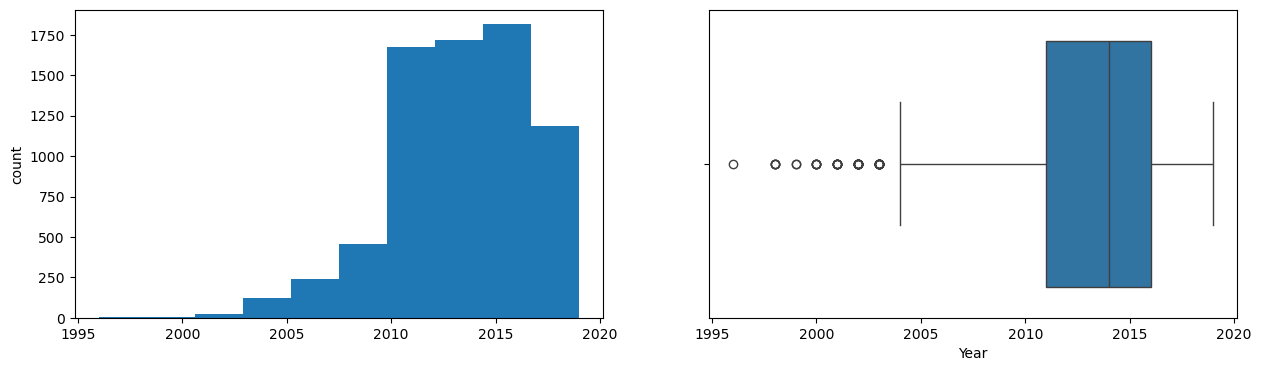

Kilometers_Driven
Skew : 61.58


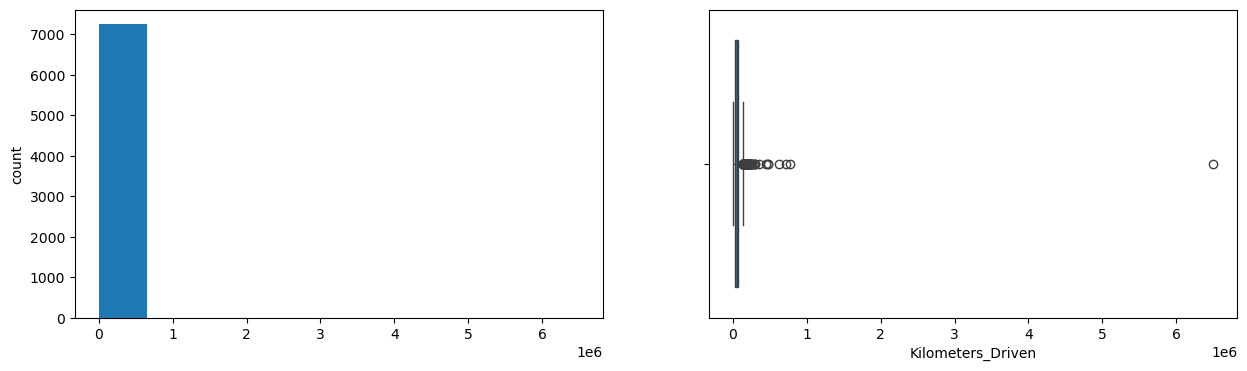

Mileage
Skew : -0.44


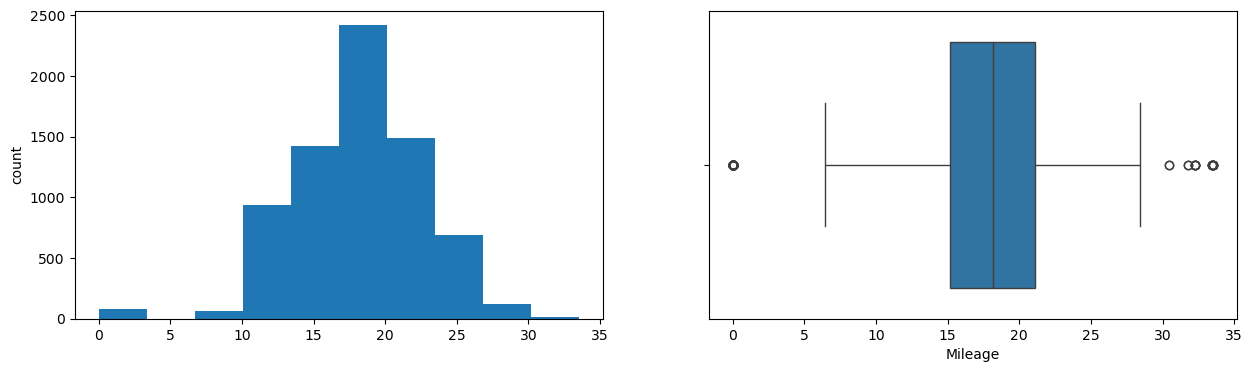

Engine
Skew : 1.41


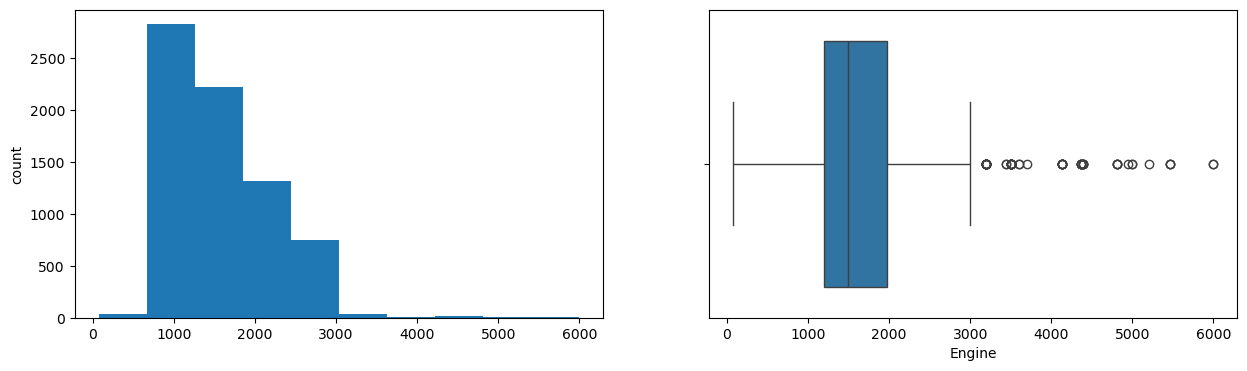

Power
Skew : 1.96


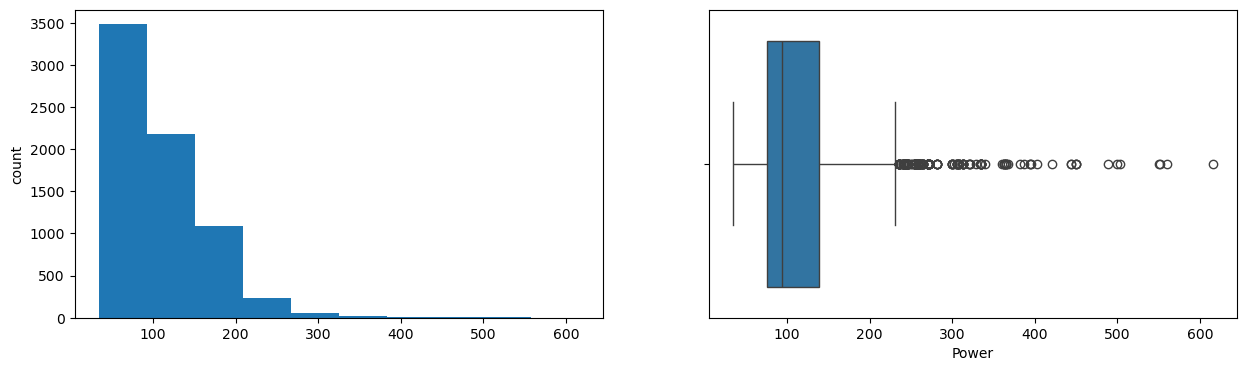

Seats
Skew : 1.9


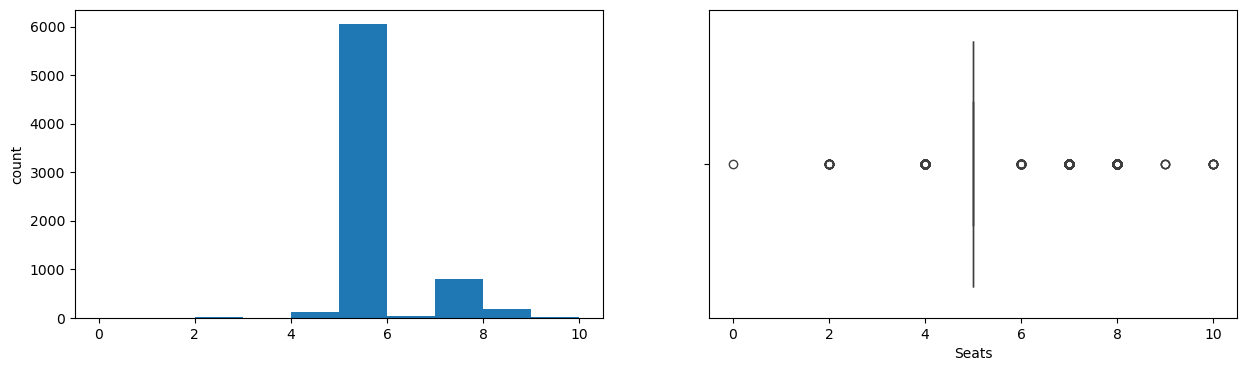

Price
Skew : 3.34


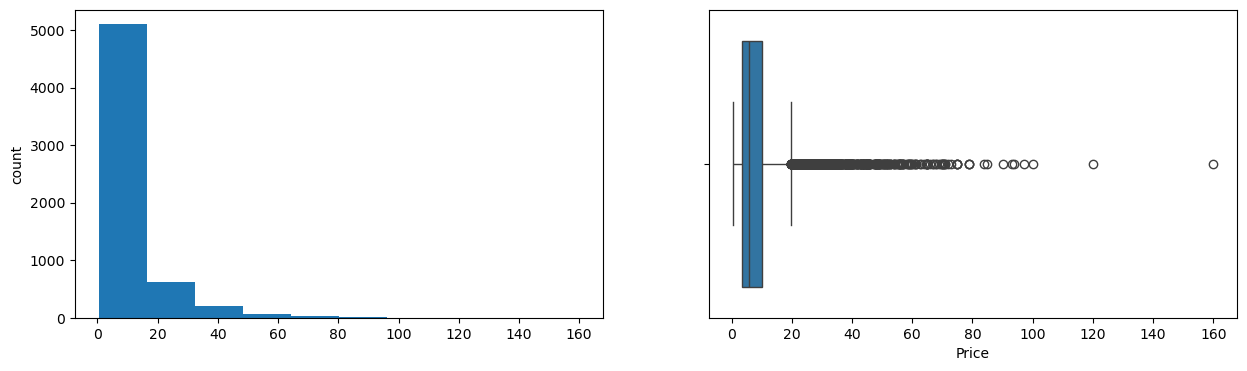

Car_Age
Skew : 0.84


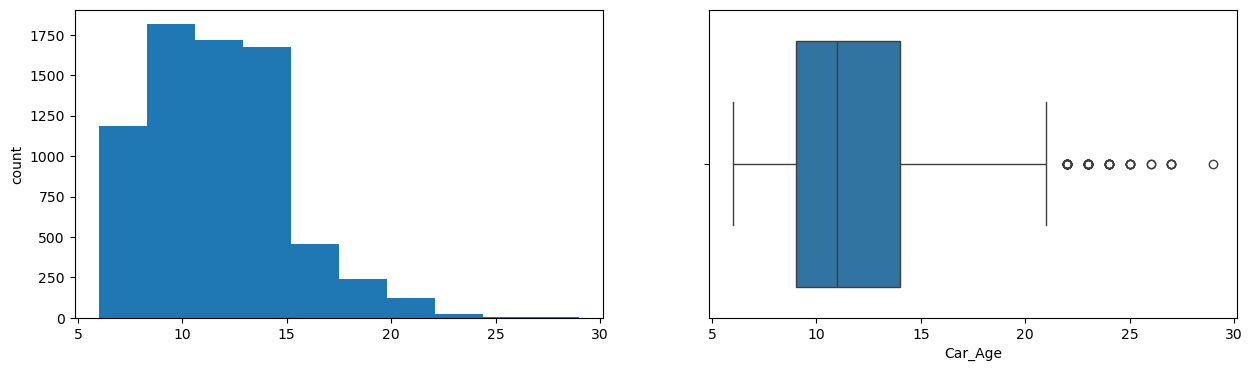

In [22]:
# Check skewness, plot histogram and box plot for numeric columns
for col in num_cols:
    print(col)
    print('Skew :', round(data[col].skew(), 2))
    plt.figure(figsize = (15, 4))
    plt.subplot(1, 2, 1)
    data[col].hist(grid=False)
    plt.ylabel('count')
    plt.subplot(1, 2, 2)
    sns.boxplot(x=data[col])
    plt.show()

Box plots can detect outliers

Price and Kilometers Driven are right skewed for this data to be transformed, and all outliers will be handled during imputation

In [23]:
def detect_outliers(df,col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3-Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    return outliers

In [24]:
for col in num_cols:
    outliers = detect_outliers(data[num_cols],col)
    print(f'Outliers in {col}: {outliers.shape[0]}')

Outliers in Year: 58
Outliers in Kilometers_Driven: 258
Outliers in Mileage: 99
Outliers in Engine: 65
Outliers in Power: 273
Outliers in Seats: 1153
Outliers in Price: 718
Outliers in Car_Age: 58


# Hypothesis Testing

In [25]:
# To compare mileage of cars with different fuel types using hypothesis testing
# null hypothesis: there is no significant difference between the means of two groups
# alternative hypothesis: there is a significant difference between the means of two groups

In [26]:
petrol_Mileage = data[data['Fuel_Type'] == 'Petrol']['Mileage']
diesel_Mileage = data[data['Fuel_Type'] == 'Diesel']['Mileage']
t_stat, p_value = stats.ttest_ind(petrol_Mileage, diesel_Mileage, equal_var=False)
print(f'T-statistic: {t_stat}, P-value: {p_value}') 
print("Diesel mean Mileage:", diesel_Mileage.mean())
print("Petrol mean Mileage:", petrol_Mileage.mean())

T-statistic: -11.59649697385999, P-value: 8.130794475634274e-31
Diesel mean Mileage: 18.633605919003113
Petrol mean Mileage: 17.433374436090226


-  p value > 0.05
<br> Hence there is no significant difference between the means of two groups

- Also the diesel mean mpg > petrol mean mpg
<br> which indicates that the diesel is more efficient fuel than petrol

Categorical variables are being visualized using a count plot.

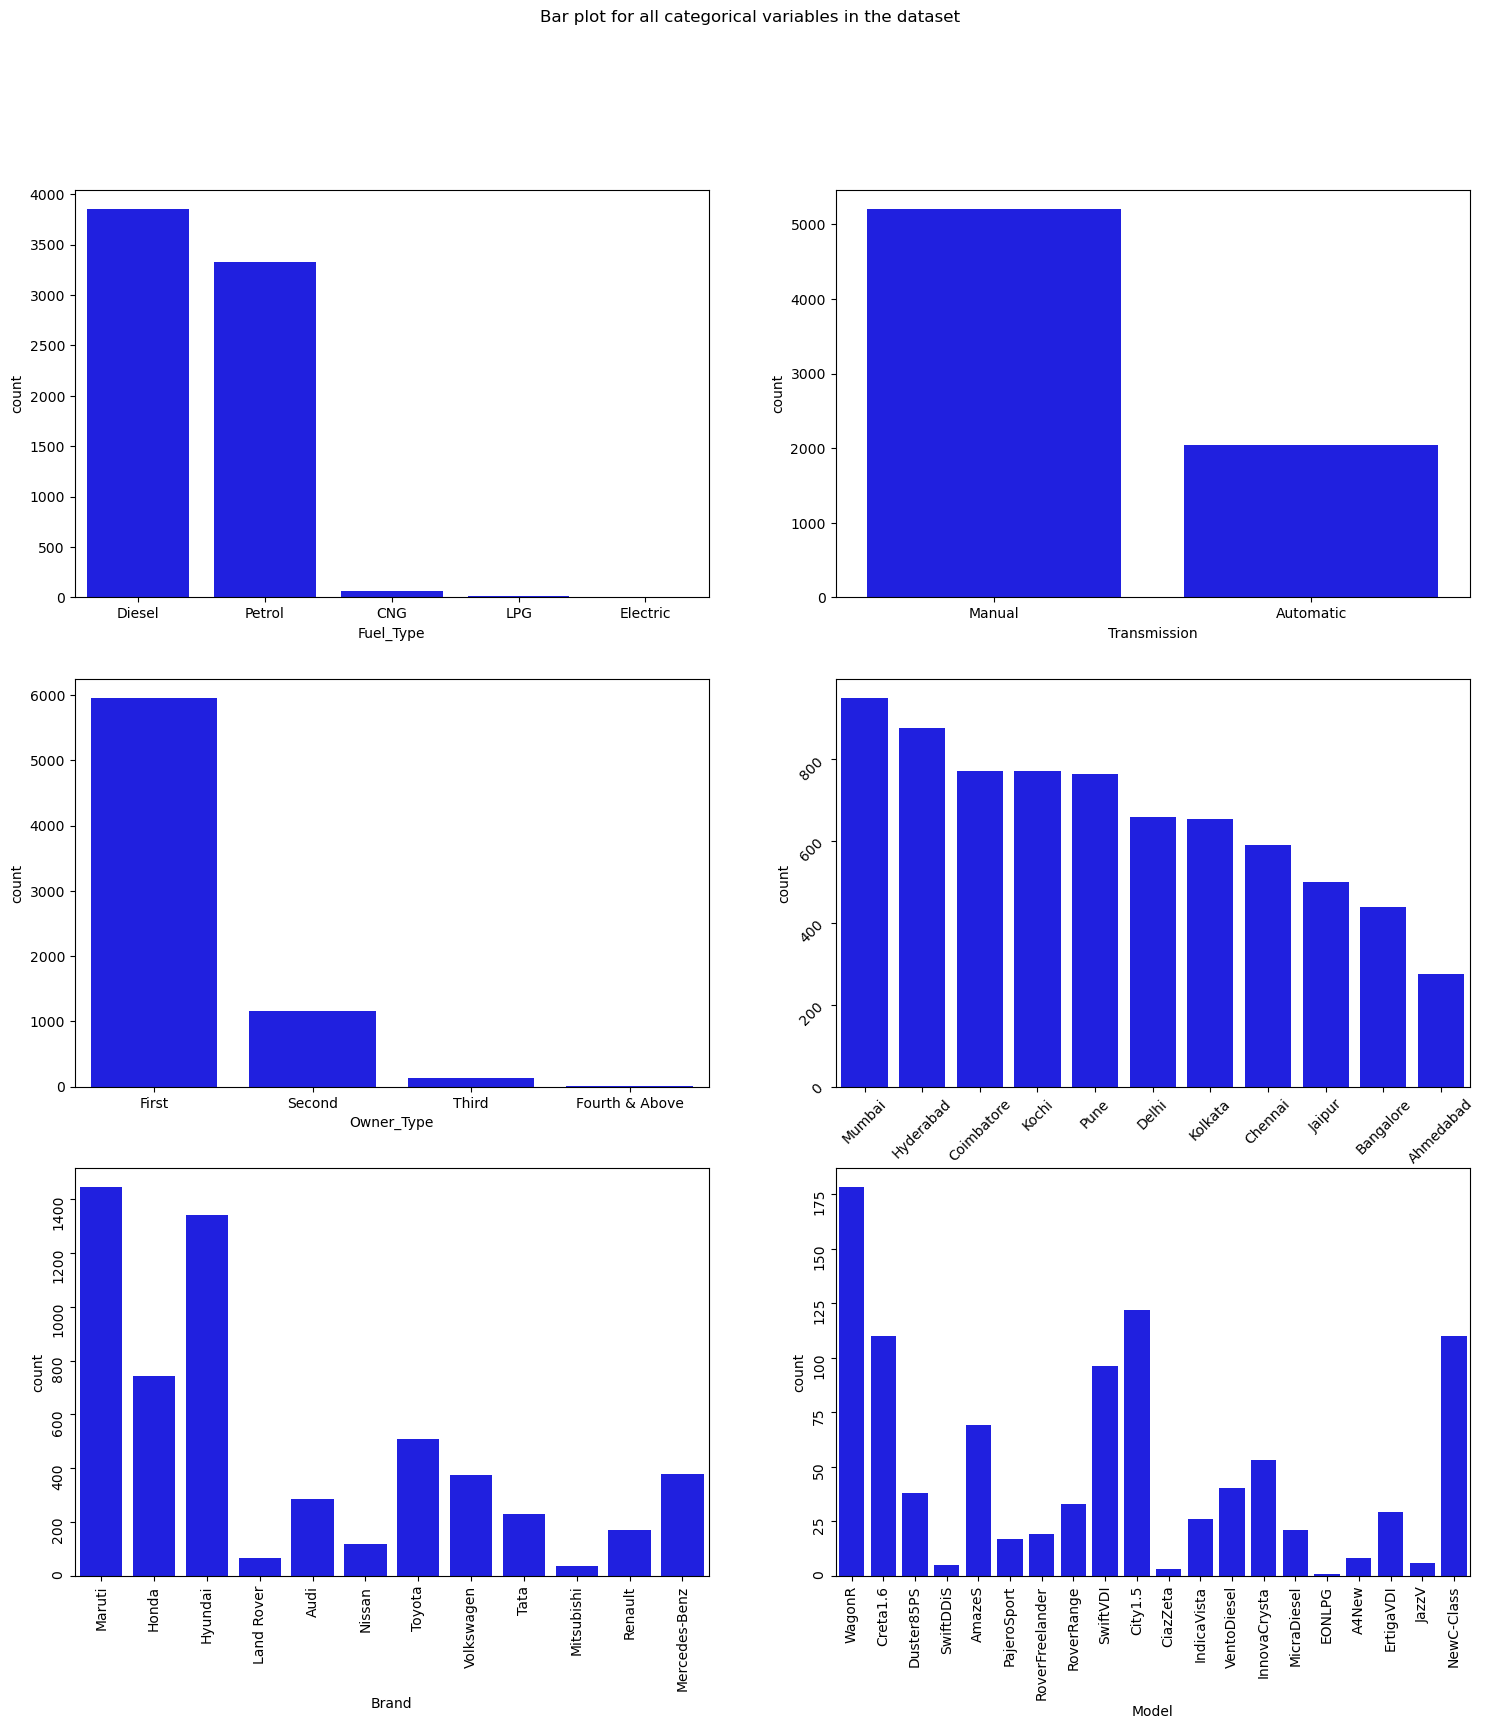

In [27]:
fig, axes = plt.subplots(3, 2, figsize = (18, 18))
fig.suptitle('Bar plot for all categorical variables in the dataset')
sns.countplot(ax = axes[0, 0], x = 'Fuel_Type', data = data, color = 'blue', 
              order = data['Fuel_Type'].value_counts().index);
sns.countplot(ax = axes[0, 1], x = 'Transmission', data = data, color = 'blue', 
              order = data['Transmission'].value_counts().index);
sns.countplot(ax = axes[1, 0], x = 'Owner_Type', data = data, color = 'blue', 
              order = data['Owner_Type'].value_counts().index);
sns.countplot(ax = axes[1, 1], x = 'Location', data = data, color = 'blue', 
              order = data['Location'].value_counts().index);
sns.countplot(ax = axes[2, 0], x = 'Brand', data = data, color = 'blue', 
              order = data['Brand'].head(20).value_counts().index);
sns.countplot(ax = axes[2, 1], x = 'Model', data = data, color = 'blue', 
              order = data['Model'].head(20).value_counts().index);
axes[1][1].tick_params(labelrotation=45);
axes[2][0].tick_params(labelrotation=90);
axes[2][1].tick_params(labelrotation=90);

From the count plot, we can have below observations

    -  Mumbai has the highest number of cars available for purchase, followed by Hyderabad and Coimbatore
    -  ~53% of cars have fuel type as Diesel this shows diesel cars provide higher performance
    -  ~72% of cars have manual transmission
    -  ~82 % of cars are First owned cars. This shows most of the buyers prefer to purchase first-owner cars
    -  ~20% of cars belong to the brand Maruti followed by 19% of cars belonging to Hyundai
    -  WagonR ranks first among all models which are available for purchase
    

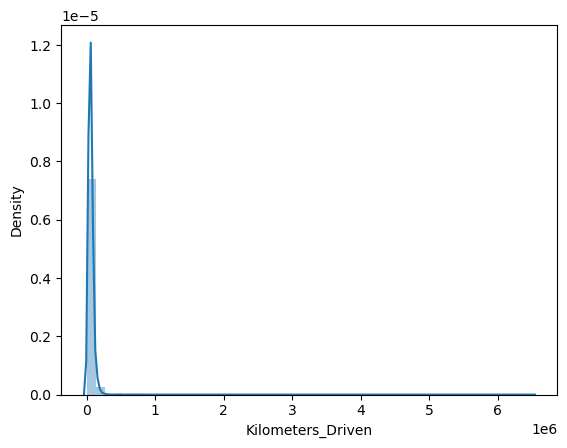

In [28]:
sns.distplot(data["Kilometers_Driven"], axlabel="Kilometers_Driven");

Data Transformation

    - Price and Kilometer-Driven variables are highly skewed and on a larger scale. Let’s do log transformation.

    - Log transformation can help in normalization, so this variable can maintain standard scale with other variables:

In [29]:
# Function for log transformation of the column
def log_transform(data,col):
    for colname in col:
        if (data[colname] <=0).all():
            data[colname + '_log'] = np.log(data[colname]+1)
        else:
            data[colname + '_log'] = np.log(data[colname])
    data.info()

In [30]:
log_transform(data,['Kilometers_Driven','Price'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7253 entries, 0 to 7252
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Name                   7253 non-null   object 
 1   Location               7253 non-null   object 
 2   Year                   7253 non-null   int64  
 3   Kilometers_Driven      7253 non-null   int64  
 4   Fuel_Type              7253 non-null   object 
 5   Transmission           7253 non-null   object 
 6   Owner_Type             7253 non-null   object 
 7   Mileage                7251 non-null   float64
 8   Engine                 7207 non-null   float64
 9   Power                  7078 non-null   float64
 10  Seats                  7200 non-null   float64
 11  New_Price              1006 non-null   object 
 12  Price                  6019 non-null   float64
 13  Car_Age                7253 non-null   int64  
 14  Brand                  7253 non-null   object 
 15  Mode

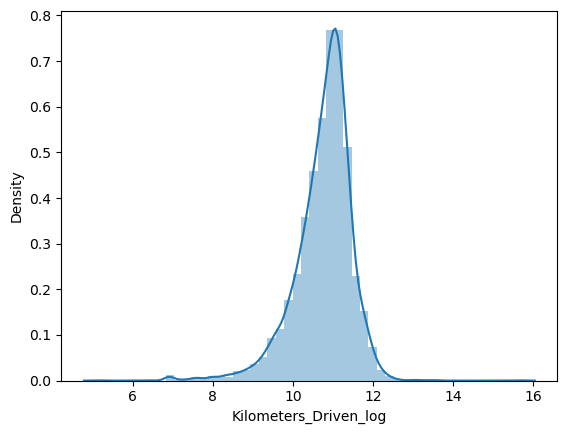

In [31]:
#Log transformation of the feature 'Kilometers_Driven'
sns.distplot(data["Kilometers_Driven_log"], axlabel="Kilometers_Driven_log");

Bivariate Analysis

<Figure size 4000x2000 with 0 Axes>

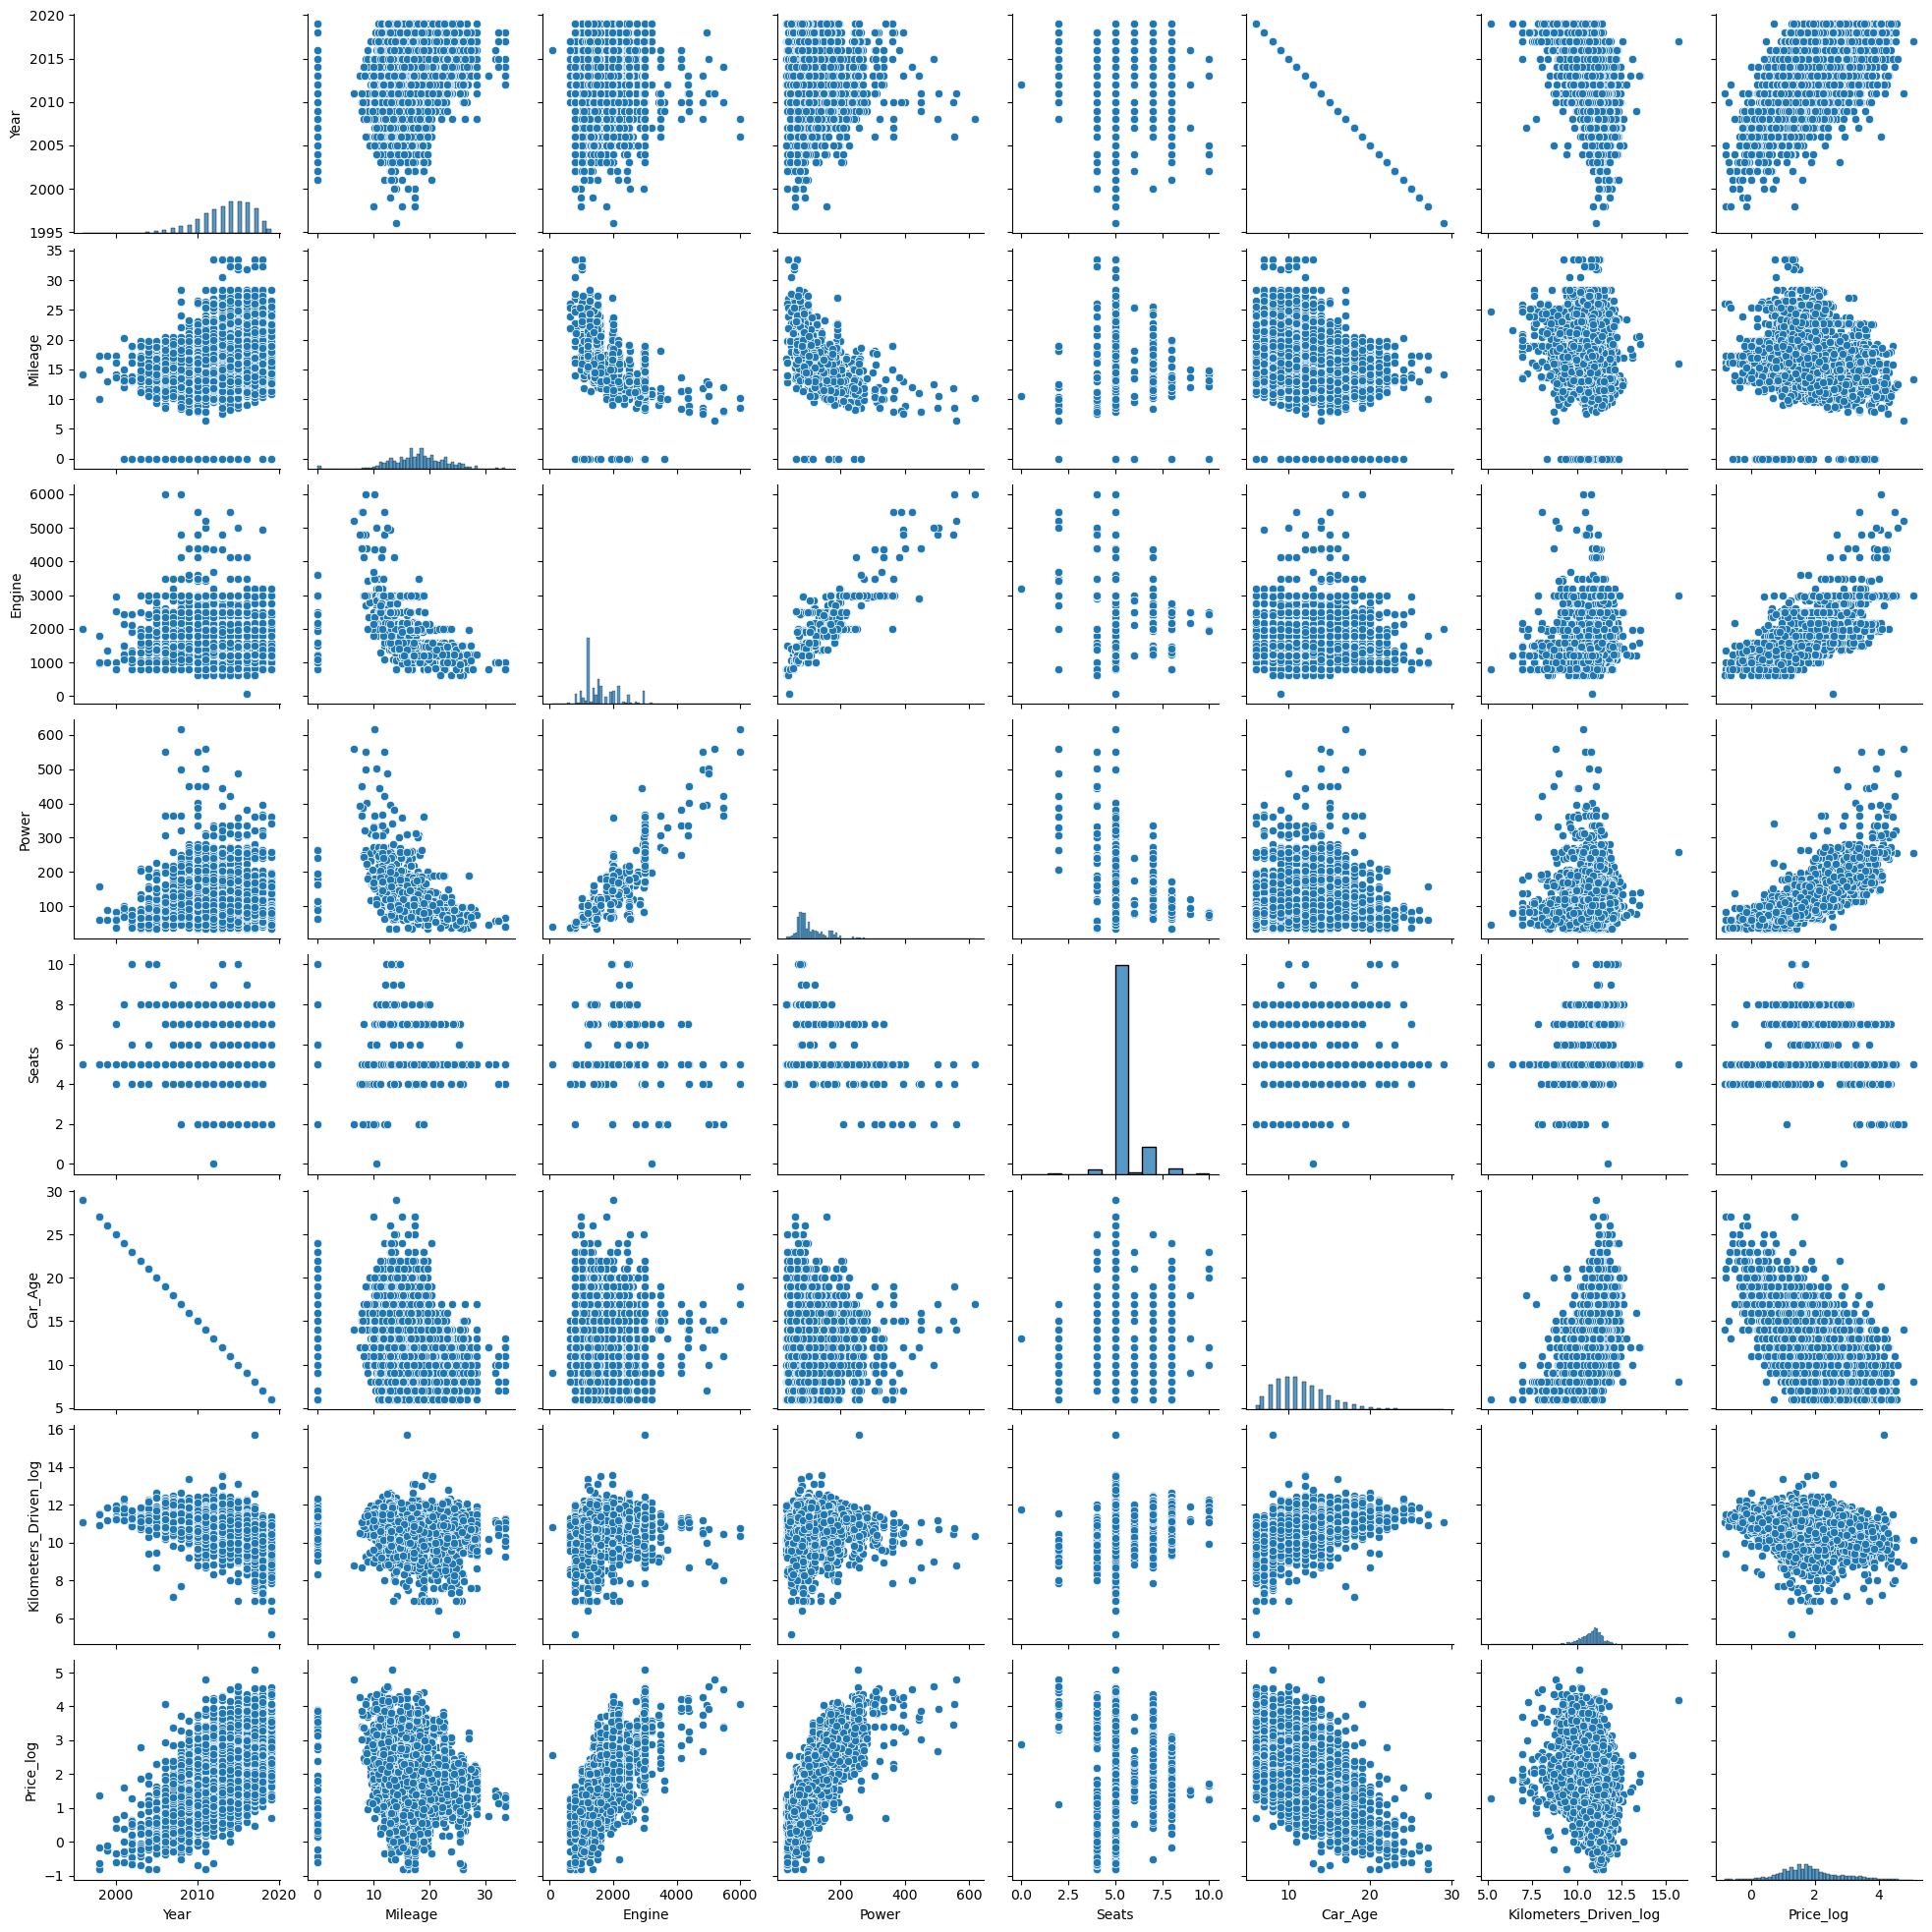

In [32]:
plt.figure(figsize=(40,20))
sns.pairplot(data=data.drop(['Kilometers_Driven','Price'],axis=1));
plt.show()

Pair Plot provides below insights:


    - The variable Year has a positive correlation with price and mileage
    - A year has a Negative correlation with kilometers-Driven
    - Car with recent make is higher at prices. As the age of the car increases price decreases
    

A bar plot can be used to show the relationship between Categorical variables and continuous variables 

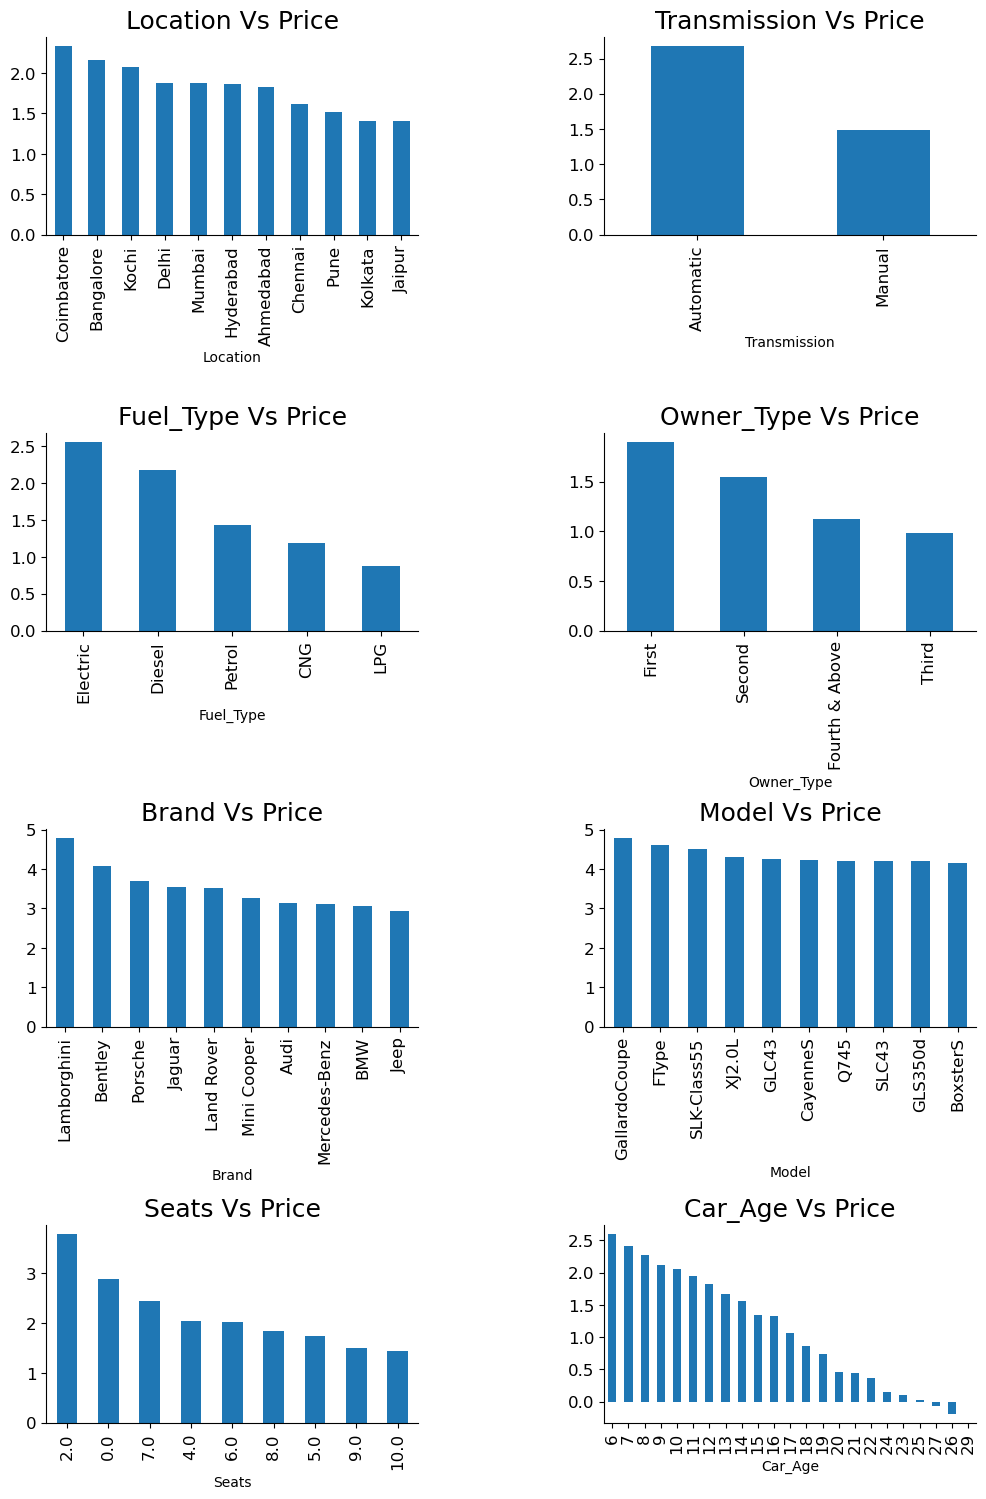

In [33]:
fig, axarr = plt.subplots(4, 2, figsize=(12, 18))
data.groupby('Location')['Price_log'].mean().sort_values(ascending=False).plot.bar(ax=axarr[0][0], fontsize=12)
axarr[0][0].set_title("Location Vs Price", fontsize=18)
data.groupby('Transmission')['Price_log'].mean().sort_values(ascending=False).plot.bar(ax=axarr[0][1], fontsize=12)
axarr[0][1].set_title("Transmission Vs Price", fontsize=18)
data.groupby('Fuel_Type')['Price_log'].mean().sort_values(ascending=False).plot.bar(ax=axarr[1][0], fontsize=12)
axarr[1][0].set_title("Fuel_Type Vs Price", fontsize=18)
data.groupby('Owner_Type')['Price_log'].mean().sort_values(ascending=False).plot.bar(ax=axarr[1][1], fontsize=12)
axarr[1][1].set_title("Owner_Type Vs Price", fontsize=18)
data.groupby('Brand')['Price_log'].mean().sort_values(ascending=False).head(10).plot.bar(ax=axarr[2][0], fontsize=12)
axarr[2][0].set_title("Brand Vs Price", fontsize=18)
data.groupby('Model')['Price_log'].mean().sort_values(ascending=False).head(10).plot.bar(ax=axarr[2][1], fontsize=12)
axarr[2][1].set_title("Model Vs Price", fontsize=18)
data.groupby('Seats')['Price_log'].mean().sort_values(ascending=False).plot.bar(ax=axarr[3][0], fontsize=12)
axarr[3][0].set_title("Seats Vs Price", fontsize=18)
data.groupby('Car_Age')['Price_log'].mean().sort_values(ascending=False).plot.bar(ax=axarr[3][1], fontsize=12)
axarr[3][1].set_title("Car_Age Vs Price", fontsize=18)
plt.subplots_adjust(hspace=1.0)
plt.subplots_adjust(wspace=.5)
sns.despine()

Observations

    - The price of cars is high in Coimbatore and less price in Kolkata and Jaipur
    - Automatic cars have more price than manual cars.
    - Diesel and Electric cars have almost the same price, which is maximum, and LPG cars have the lowest price
    - First-owner cars are higher in price, followed by a second
    - The third owner’s price is lesser than the Fourth and above
    - Lamborghini brand is the highest in price
    - Gallardocoupe Model is the highest in price
    - 2 Seater has the highest price followed by 7 Seater
    - The latest model cars are high in price

## Multivariate Analysis
A heat map is widely been used for Multivariate Analysis

Heat Map gives the correlation between the variables, whether it has a positive or negative correlation.

In [35]:
label_cols = data.select_dtypes(include=['object']).columns
le = LabelEncoder()

for col in label_cols:
    data[col] = le.fit_transform(data[col])


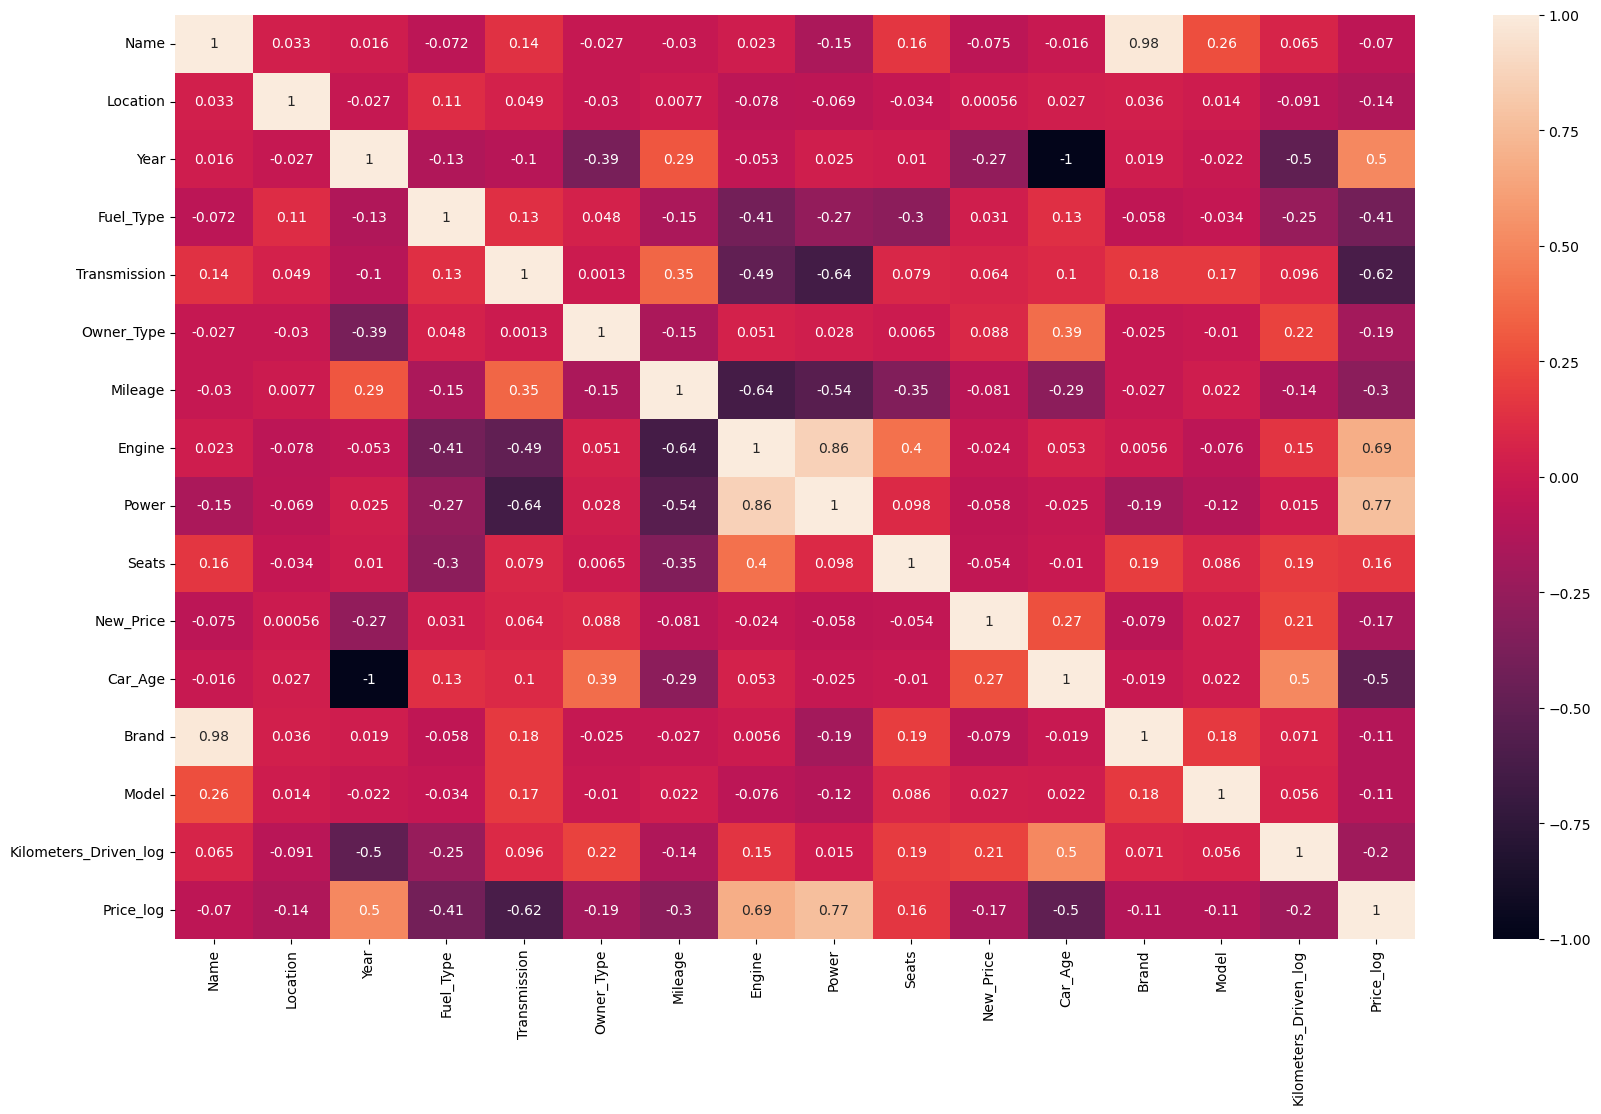

In [43]:
data = data.drop(['Kilometers_Driven','Price'],axis=1)
plt.figure(figsize=(20, 12))
sns.heatmap(data.corr(), annot=True)
plt.show()

From the Heat map, we can infer the following:

    - The engine has a strong positive correlation to Power 0.86
    - Price has a positive correlation to Engine 0.69 as well Power 0.77
    - Mileage has correlated to Engine, Power, and Price negatively
    - Price is moderately positive in correlation to year.
    - Kilometer driven has a negative correlation to year not much impact on the price
    - Car age has a negative correlation with Price
    - Car age positively correlates with kilometers driven, as the age of the car increases, the kilometers driven also increase. In contrast, car age negatively correlates with mileage, which makes sense.

# Impute Missing values

In [44]:
data.loc[data["Mileage"]==0.0,'Mileage']=np.nan
data.Mileage.isnull().sum()

0

In [45]:
data['Mileage'].fillna(value=np.mean(data['Mileage']),inplace=True)

In [46]:
data.Seats.isnull().sum()

22

In [47]:
data['Seats'].fillna(value=np.nan,inplace=True)
data['Seats']  = data.groupby(['Brand','Model'])['Seats'] .transform(lambda x: x.fillna(x.median()))
data['Engine'] = data.groupby(['Brand','Model'])['Engine'].transform(lambda x: x.fillna(x.median()))
data['Power']  = data.groupby(['Brand','Model'])['Power'] .transform(lambda x: x.fillna(x.median()))

In [48]:
data.head()

,Name,Location,Year,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Car_Age,Brand,Model,Kilometers_Driven_log,Price_log
0,1310,9,2010,0,1,0,26.60,998.0,58.16,5.0,625,15,18,649,11.184421,0.559616
1,560,10,2015,1,1,0,19.67,1582.0,126.20,5.0,625,10,11,177,10.621327,2.525729
2,529,2,2011,4,1,0,18.20,1199.0,88.70,5.0,557,14,10,343,10.736397,1.504077
3,1160,2,2012,1,1,0,20.77,1248.0,88.76,7.0,625,13,18,244,11.373663,1.791759
4,23,3,2013,1,0,2,15.20,1968.0,140.80,5.0,625,12,1,21,10.613246,2.875822


In [49]:
data.describe(include='all')

,Name,Location,Year,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Car_Age,Brand,Model,Kilometers_Driven_log,Price_log
count,7253.000000,7253.000000,7253.000000,7253.000000,7253.000000,7253.000000,7253.000000,7235.000000,7190.000000,7231.000000,7253.000000,7253.000000,7253.000000,7253.000000,7253.000000,6019.000000
mean,998.547773,5.622363,2013.365366,2.370330,0.717496,0.375982,18.346527,1616.271873,112.309517,5.279076,581.460085,11.634634,15.834689,367.197711,10.760978,1.825095
std,577.521935,2.969663,3.254421,1.504603,0.450248,0.815908,4.134048,594.752387,53.405544,0.810616,127.497172,3.254421,8.181922,226.721579,0.716327,0.874059
min,0.000000,0.000000,1996.000000,0.000000,0.000000,0.000000,6.400000,72.000000,34.200000,0.000000,0.000000,6.000000,0.000000,0.000000,5.141664,-0.820981
25%,514.000000,3.000000,2011.000000,1.000000,0.000000,0.000000,15.400000,1198.000000,74.000000,5.000000,625.000000,9.000000,10.000000,169.000000,10.434116,1.252763
50%,1017.000000,6.000000,2014.000000,1.000000,1.000000,0.000000,18.346527,1493.000000,93.700000,5.000000,625.000000,11.000000,17.000000,334.000000,10.885866,1.729884
75%,1434.000000,8.000000,2016.000000,4.000000,1.000000,0.000000,21.100000,1968.000000,138.080000,5.000000,625.000000,14.000000,19.000000,581.000000,11.198215,2.297573
max,2040.000000,10.000000,2019.000000,4.000000,1.000000,3.000000,33.540000,5998.000000,616.000000,10.000000,625.000000,29.000000,31.000000,726.000000,15.687313,5.075174
